In [1]:
import torch

import sys
sys.path.append('../../src')
sys.path.append('/shared_data0/weiqiuy/api_keys')
from data_utils import get_nsf_data_proc
from model_utils import get_model
from eval_utils import Metrics, evaluate_model

ROOT_DIR = '/shared_data0/weiqiuy/nsf-awards'
debug = True

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [21]:
import pandas as pd

def results_to_latex(
    results_all_aggr,
    float_fmt="{:.3f}",
    sep=" $\\pm$ ",
    caption="Aggregated metrics (transposed)",
    label="tab:metrics_transposed",
    column_format=None
):
    """
    Like results_to_latex, but metrics ↔ methods are swapped,
    and all '_' in names are replaced by '-'.
    """
    # 1) Gather all unique metrics
    all_metrics = sorted({
        metric.replace("_", "-")
        for method_dict in results_all_aggr.values()
        for metric in method_dict.keys()
    })

    # 2) Build rows, replacing '_' → '-' in method names
    rows = []
    for method, metrics_dict in results_all_aggr.items():
        method_name = method.replace("_", "-")
        row = {"Method": method_name}
        for m in all_metrics:
            # find the original metric key by mapping back dashes to underscores
            orig_metric = m.replace("-", "_")
            if orig_metric in metrics_dict:
                mean, std = metrics_dict[orig_metric]
                row[m] = f"{float_fmt.format(mean)}{sep}{float_fmt.format(std)}"
            else:
                row[m] = ""
        rows.append(row)

    # 3) Make DataFrame and set index
    df = pd.DataFrame(rows).set_index("Method")

    # 4) Transpose and rename index
    df = df.T
    df.index.name = "Metric"

    # 5) Replace any remaining '_' in the DataFrame index just in case
    df.index = df.index.str.replace("_", "-")

    # 6) Auto-generate column_format if not provided
    if column_format is None:
        column_format = "l" + "r" * df.shape[1]

    # 7) Export to LaTeX
    return df.to_latex(
        escape=False,
        column_format=column_format,
        caption=caption,
        label=label
    )


In [53]:
import numpy as np
import pandas as pd
from collections.abc import Mapping

def _flatten_dict(d, parent_key="", sep="_"):
    """Recursively flatten a nested mapping into { key: np.array(...) }."""
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, Mapping):
            yield from _flatten_dict(v, new_key, sep=sep)
        else:
            yield new_key, np.asarray(v)

def bootstrap_std(values, n_bootstrap=1000, seed=42):
    """Bootstrap σ of the mean."""
    rng = np.random.default_rng(seed)
    values = np.atleast_1d(values)
    if values.size <= 1:
        return 0.0
    n = values.size
    res = rng.choice(values, size=(n_bootstrap, n), replace=True)
    return res.mean(axis=1).std(ddof=1)

def results_to_latex_by_directorate(
    raw_results_all,
    directorates,
    float_fmt="{:.3f}",
    sep=" $\\pm$ ",
    caption="Technical → Non‐Technical Abstracts",
    label="tab:tech2nontech",
    column_format=None
):
    """
    raw_results_all : dict[method_name -> nested dict of per-sample lists]
    directorates     : list[str] of length N (one entry per sample)
    """
    methods = list(raw_results_all.keys())
    N = len(directorates)

    # 1) flatten each method separately:
    #    flat[method][metric] = np.array length N
    flat = {}
    for m in methods:
        flat[m] = dict(_flatten_dict(raw_results_all[m], sep="_"))

    # 2) gather union of all metric keys
    metrics = sorted({k for md in flat.values() for k in md.keys()})

    # 3) unique directorates in order of appearance
    dirs = []
    for d in directorates:
        if d not in dirs:
            dirs.append(d)

    # 4) prepare the LaTeX lines
    n_methods = len(methods)
    # default column format: l + r*#methods
    if column_format is None:
        column_format = "l" + "r" * n_methods

    lines = []
    lines.append(r"\begin{table}[ht]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(rf"\begin{{tabular}}{{{column_format}}}")
    lines.append(r"\toprule")

    # Header: blank Metric column + method names
    hdr = "Metric "
    for m in methods:
        hdr += rf"& {m.replace('_','-')} "
    hdr += r"\\"
    lines.append(hdr)
    lines.append(r"\midrule")

    # 5) for each directorate block
    arr_dirs = np.array(directorates)
    for d in dirs:
        # sub-header row
        lines.append(
            rf"\multicolumn{{{n_methods+1}}}{{l}}{{\bfseries {d.replace('_','-')}}} \\"
        )
        lines.append(r"\addlinespace[0.3em]")

        mask = (arr_dirs == d)
        # rows per metric
        for k in metrics:
            row = [k.replace("_","-")]
            for m in methods:
                vals = flat[m].get(k, np.array([]))[mask]
                if vals.size:
                    mu = np.mean(vals)
                    sd = bootstrap_std(vals)
                    val = f"{float_fmt.format(mu)}{sep}{float_fmt.format(sd)}"
                else:
                    val = ""
                row.append(val)
            lines.append(" & ".join(row) + r"\\")
        lines.append(r"\addlinespace[0.5em]")

    # Footer
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    return "\n".join(lines)


# [tech2nontech] Technical Abstract to Nontechnical Abstract

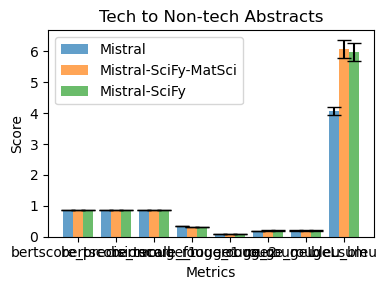

In [28]:
import os
import numpy as np
import json
from collections import defaultdict
from data_utils import load_jsonl
from vis_utils import plot_grouped_bar_adjustable_width, bootstrap_std

import numpy as np
from collections.abc import Mapping

def bootstrap_std(values):
    values = np.atleast_1d(values)      # scalar → 1-element array
    n = values.size
    if n == 1:
        return 0.0                      # no variation possible
    resamples = rng.choice(values, size=(n_bootstrap, n), replace=True)
    means = resamples.mean(axis=1)
    return means.std(ddof=1)


def _flatten_dict(d, parent_key="", sep="_"):
    """
    Recursively walk a (possibly) nested mapping and yield
    (compound_key, leaf_value) pairs.  Non-mapping values are treated
    as leaves.
    """
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, Mapping):
            # keep descending
            yield from _flatten_dict(v, new_key, sep=sep)
        else:
            # reached a leaf (assumed iterable of numbers)
            yield new_key, v
            
def analyze(results, metrics_keep=None, sep="_", *, n_bootstrap=1000, seed=42):
    """
    Parameters
    ----------
    results : Mapping
        Arbitrary nesting of dictionaries whose leaves are 1-D arrays / lists.
    metrics_keep : container of str, optional
        If given, only these flattened metric names are returned.
    sep : str
        Separator used when chaining keys.
    n_bootstrap : int
        Number of bootstrap resamples for std estimation.
    seed : int
        Random seed for bootstrap resampling.
    """
    rng = np.random.default_rng(seed)

    def bootstrap_std(values):
        values = np.asarray(values)
        n = len(values)
        resamples = rng.choice(values, size=(n_bootstrap, n), replace=True)
        means = resamples.mean(axis=1)
        return means.std(ddof=1)          # bootstrap σ of the mean

    analysis = {}
    for metric_name, values in _flatten_dict(results, sep=sep):
        if not isinstance(values, (list, tuple, np.ndarray)):
            raise ValueError(
                f"Leaf '{metric_name}' is a scalar ({values!r}); "
                "expected a list/array of numbers."
            )

        if metrics_keep is not None and metric_name not in metrics_keep:
            continue

        values = np.asarray(values)
        mean_val = values.mean()
        std_val = bootstrap_std(values)
        analysis[metric_name] = (mean_val, std_val)

    return analysis
            
results_path = '../../metrics/tech2nontech_final_scores.json'

with open(results_path, 'rt') as input_file:
    results_all = json.load(input_file)
    
results_all_aggr = {}
for key, nested in results_all.items():
    results_all_aggr[key] = analyze(nested)

    
# Running the function with your dataset
plot_grouped_bar_adjustable_width(results_all_aggr, 
                                  save_path='../figures/tech2nontech_final.pdf',
                                  figsize=(4, 3),
                                 rotation=0, ha='center',
                                 title='Tech to Non-tech Abstracts')

In [29]:
latex_tbl = results_to_latex(results_all_aggr,
                                        float_fmt="{:.4f}",
                                        caption="Techical to Non-Technical Abstracts",
                                        label="tab:tech2nontech")
print(latex_tbl)


\begin{table}
\centering
\caption{Techical to Non-Technical Abstracts}
\label{tab:tech2nontech}
\begin{tabular}{lrrr}
\toprule
Method &              Mistral & Mistral-SciFy-MatSci &        Mistral-SciFy \\
Metric              &                      &                      &                      \\
\midrule
bertscore-f1        &  0.8514 $\pm$ 0.0003 &  0.8487 $\pm$ 0.0005 &  0.8500 $\pm$ 0.0006 \\
bertscore-precision &  0.8515 $\pm$ 0.0003 &  0.8472 $\pm$ 0.0007 &  0.8513 $\pm$ 0.0007 \\
bertscore-recall    &  0.8516 $\pm$ 0.0003 &  0.8508 $\pm$ 0.0004 &  0.8496 $\pm$ 0.0005 \\
bleu-bleu           &  4.0797 $\pm$ 0.0647 &  6.0812 $\pm$ 0.1457 &  5.9850 $\pm$ 0.1444 \\
rouge-rouge1        &  0.3351 $\pm$ 0.0013 &  0.3162 $\pm$ 0.0023 &  0.3141 $\pm$ 0.0023 \\
rouge-rouge2        &  0.0705 $\pm$ 0.0008 &  0.0953 $\pm$ 0.0017 &  0.0936 $\pm$ 0.0016 \\
rouge-rougeL        &  0.1773 $\pm$ 0.0008 &  0.1944 $\pm$ 0.0016 &  0.1967 $\pm$ 0.0016 \\
rouge-rougeLsum     &  0.1982 $\pm$ 0.0010 &  0.1

/tmp/ipykernel_19536/460388067.py:52: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return df.to_latex(


## Categories

In [30]:
load_paths = {
    '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/tech2nontech/mistral-7b-instruct-v0.3_preds.json': 'Mistral',
    '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/tech2nontech/lora_model_mistral-7b-instruct-v0.3_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm_preds.json': 'Mistral-SciFy-MatSci',
    '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/tech2nontech/lora_model_mistral-7b-instruct-v0.3.tech2nontech_instruct_user_assistant.matsci_and_20k.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds.json': 'Mistral-SciFy'
}

In [32]:
load_path = list(load_paths.keys())[0]
with open(load_path) as input_file:
    data = json.load(input_file)

In [44]:
keep_directorates = ['MPS', 'GEO', 'ENG', 'CSE', 'BIO']

directorates = []
for i in range(len(data['inputs'])):
    if data['inputs'][i]['division'] == 'DMR' \
        or data['inputs'][i]['directorate'] not in keep_directorates:
        directorates.append('DMR')
    else:
        directorates.append(data['inputs'][i]['directorate'])

In [46]:
len(directorates), directorates[:10]

(3764, ['DMR', 'DMR', 'DMR', 'DMR', 'DMR', 'DMR', 'DMR', 'DMR', 'DMR', 'DMR'])

In [37]:
data['inputs'][0]['directorate']

'MPS'

In [56]:
# `results_all` is your JSON-loaded raw dict:
#   { "Mistral": {...}, "Mistral-SciFy": {...}, ... }

# `directorates` is your list of length N, e.g.:
#   ["DMR","DMR","ENG",...,"BIO"]

latex = results_to_latex_by_directorate(
    raw_results_all = results_all,
    directorates     = directorates,
    float_fmt        = "{:.4f}",
    sep              = " $\\pm$ ",
    caption          = "Technical to Non-Technical Abstracts",
    label            = "tab:tech2nontech_detailed",
)
print(latex)


\begin{table}[ht]
\centering
\caption{Technical to Non-Technical Abstracts}
\label{tab:tech2nontech_detailed}
\begin{tabular}{lrrr}
\toprule
Metric & Mistral & Mistral-SciFy-MatSci & Mistral-SciFy \\
\midrule
\multicolumn{4}{l}{\bfseries DMR} \\
\addlinespace[0.3em]
bertscore-f1 & 0.8531 $\pm$ 0.0004 & 0.8560 $\pm$ 0.0007 & 0.8567 $\pm$ 0.0007\\
bertscore-precision & 0.8532 $\pm$ 0.0005 & 0.8556 $\pm$ 0.0009 & 0.8578 $\pm$ 0.0009\\
bertscore-recall & 0.8533 $\pm$ 0.0005 & 0.8569 $\pm$ 0.0006 & 0.8563 $\pm$ 0.0006\\
bleu-bleu & 4.9838 $\pm$ 0.1042 & 8.3913 $\pm$ 0.2428 & 8.3805 $\pm$ 0.2446\\
rouge-rouge1 & 0.3515 $\pm$ 0.0019 & 0.3498 $\pm$ 0.0032 & 0.3515 $\pm$ 0.0032\\
rouge-rouge2 & 0.0827 $\pm$ 0.0013 & 0.1238 $\pm$ 0.0027 & 0.1217 $\pm$ 0.0026\\
rouge-rougeL & 0.1893 $\pm$ 0.0013 & 0.2210 $\pm$ 0.0025 & 0.2223 $\pm$ 0.0025\\
rouge-rougeLsum & 0.2135 $\pm$ 0.0015 & 0.2259 $\pm$ 0.0026 & 0.2271 $\pm$ 0.0026\\
\addlinespace[0.5em]
\multicolumn{4}{l}{\bfseries BIO} \\
\addlinespace[0.

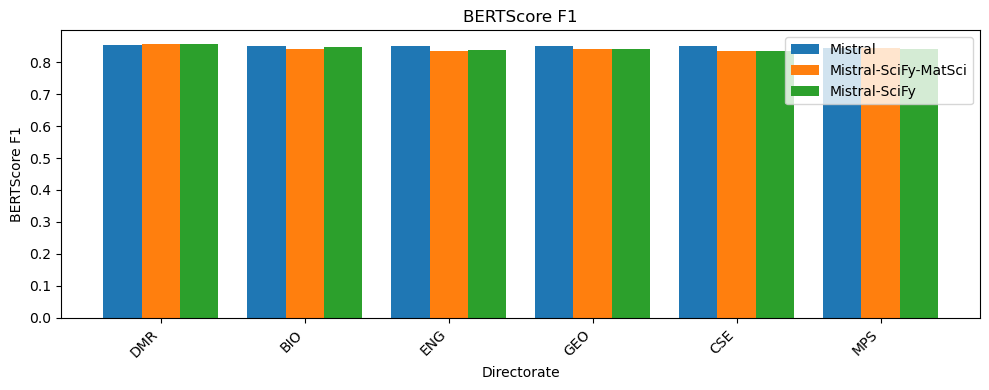

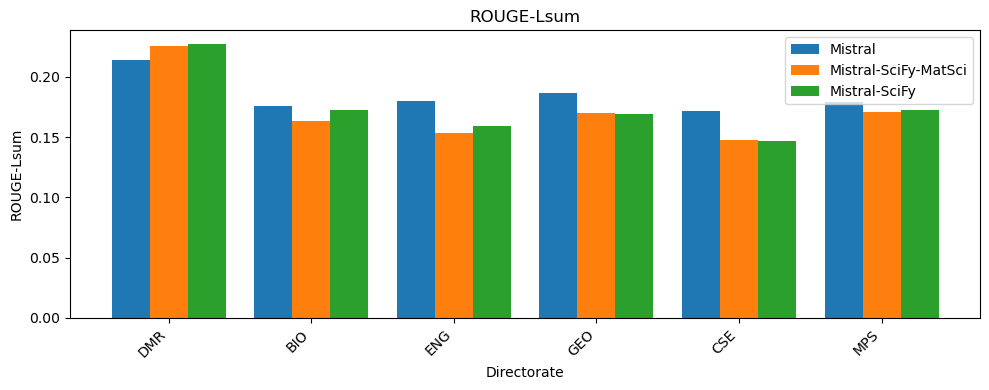

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Mapping

def _flatten_dict(d, parent_key="", sep="_"):
    """Recursively flatten nested dict into {key: np.array}."""
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, Mapping):
            yield from _flatten_dict(v, new_key, sep=sep)
        else:
            yield new_key, np.asarray(v)

# ─────────────────────────────────────────────────────────────────────────────
# 1) Flatten every model's raw per-sample lists into arrays
# raw_results_all: dict[method → nested dict of length-N lists]
raw_results_all = results_all
flat = {
    method: dict(_flatten_dict(raw_results_all[method], sep="_"))
    for method in raw_results_all
}

# 2) Unique directorates in order
dirs = []
for d in directorates:
    if d not in dirs:
        dirs.append(d)
arr_dirs = np.array(directorates)

# 3) Which metrics to plot
to_plot = {
    "BERTScore F1": "bertscore_f1",
    "ROUGE-Lsum":  "rouge_rougeLsum"
}

# 4) Generate one plot per metric
for title, key in to_plot.items():
    methods = list(raw_results_all.keys())
    
    # compute mean per directorate
    means = {
        m: [
            flat[m].get(key, np.array([]))[arr_dirs == d].mean()
            for d in dirs
        ]
        for m in methods
    }

    x     = np.arange(len(dirs))
    width = 0.8 / len(methods)

    plt.figure(figsize=(10, 4))
    for i, m in enumerate(methods):
        plt.bar(x + i*width, means[m], width, label=m.replace("_","-"))
    plt.xticks(x + width*(len(methods)-1)/2, dirs, rotation=45, ha="right")
    plt.xlabel("Directorate")
    plt.ylabel(title)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'tech2nontech_by_directorate_{title}.pdf', dpi=300, bbox_inches='tight', pad_inches=0)


# [text2claims] Techincal Abstract and Nontechnical Abstract to Verifiable Claims

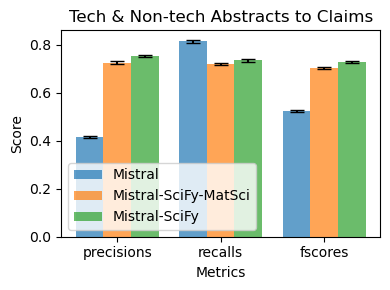

In [63]:
import os
import numpy as np
import json
from collections import defaultdict
from data_utils import load_jsonl
from vis_utils import analyze, plot_grouped_bar_adjustable_width, bootstrap_std


results_path = '../../metrics/technontech2claims_final_scores.json'

with open(results_path, 'rt') as input_file:
    results_all = json.load(input_file)
    
results_all_aggr = {}
for key in results_all:
    aggr_results = analyze(results_all[key],
                                        metrics_keep=[
                                            'precisions',
                                            'recalls',
                                            'fscores'])
    results_all_aggr[key] = aggr_results
    
# Running the function with your dataset
plot_grouped_bar_adjustable_width(results_all_aggr, 
                                  save_path='../figures/technontech2claims_final.pdf',
                                  figsize=(4, 3),
                                 rotation=0, ha='center',
                                 title='Tech & Non-tech Abstracts to Claims')

In [64]:
latex_tbl = results_to_latex(results_all_aggr,
                                        float_fmt="{:.4f}",
                                        caption="Tech & Non-Tech Abstracts to Claims",
                                        label="tab:text2claims")
print(latex_tbl)


\begin{table}
\centering
\caption{Tech & Non-Tech Abstracts to Claims}
\label{tab:text2claims}
\begin{tabular}{lrrr}
\toprule
Method &              Mistral & Mistral-SciFy-MatSci &        Mistral-SciFy \\
Metric     &                      &                      &                      \\
\midrule
fscores    &  0.5247 $\pm$ 0.0024 &  0.7033 $\pm$ 0.0024 &  0.7268 $\pm$ 0.0024 \\
precisions &  0.4146 $\pm$ 0.0025 &  0.7257 $\pm$ 0.0027 &  0.7526 $\pm$ 0.0026 \\
recalls    &  0.8141 $\pm$ 0.0027 &  0.7203 $\pm$ 0.0026 &  0.7354 $\pm$ 0.0026 \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_19536/460388067.py:52: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return df.to_latex(


# Categories

In [65]:
load_paths = {
    '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/technontech2claims/lora_model_mistral-7b-instruct-v0.3.text2claims_instruct_user_assistant.matsci_and_20k.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds.json': 'Mistral',
    '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/technontech2claims/lora_model_mistral-7b-instruct-v0.3.text2claims_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds.json': 'Mistral-SciFy-MatSci',
    '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/technontech2claims/mistral-7b-instruct-v0.3_preds.json': 'Mistral-SciFy'
    # '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/tech2nontech/mistral-7b-instruct-v0.3_preds.json': 'Mistral',
    # '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/tech2nontech/lora_model_mistral-7b-instruct-v0.3_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm_preds.json': 'Mistral-SciFy-MatSci',
    # '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/tech2nontech/lora_model_mistral-7b-instruct-v0.3.tech2nontech_instruct_user_assistant.matsci_and_20k.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds.json': 'Mistral-SciFy'
}

load_path = list(load_paths.keys())[0]
with open(load_path) as input_file:
    data = json.load(input_file)

keep_directorates = ['MPS', 'GEO', 'ENG', 'CSE', 'BIO']

directorates = []
for i in range(len(data['inputs'])):
    if data['inputs'][i]['division'] == 'DMR' \
        or data['inputs'][i]['directorate'] not in keep_directorates:
        directorates.append('DMR')
    else:
        directorates.append(data['inputs'][i]['directorate'])
len(directorates)

6000

In [66]:
# `results_all` is your JSON-loaded raw dict:
#   { "Mistral": {...}, "Mistral-SciFy": {...}, ... }

# `directorates` is your list of length N, e.g.:
#   ["DMR","DMR","ENG",...,"BIO"]

latex = results_to_latex_by_directorate(
    raw_results_all = results_all,
    directorates     = directorates,
    float_fmt        = "{:.4f}",
    sep              = " $\\pm$ ",
    caption          = "Technical + Non-Technical Abstracts to Claims",
    label            = "tab:text2claims_detailed",
)
print(latex)


\begin{table}[ht]
\centering
\caption{Technical + Non-Technical Abstracts to Claims}
\label{tab:text2claims_detailed}
\begin{tabular}{lrrr}
\toprule
Metric & Mistral & Mistral-SciFy-MatSci & Mistral-SciFy \\
\midrule
\multicolumn{4}{l}{\bfseries DMR} \\
\addlinespace[0.3em]
fscores & 0.5078 $\pm$ 0.0038 & 0.6994 $\pm$ 0.0039 & 0.7231 $\pm$ 0.0036\\
precisions & 0.3900 $\pm$ 0.0036 & 0.7323 $\pm$ 0.0042 & 0.7517 $\pm$ 0.0040\\
recalls & 0.8182 $\pm$ 0.0043 & 0.7025 $\pm$ 0.0042 & 0.7266 $\pm$ 0.0042\\
\addlinespace[0.5em]
\multicolumn{4}{l}{\bfseries BIO} \\
\addlinespace[0.3em]
fscores & 0.5481 $\pm$ 0.0064 & 0.7435 $\pm$ 0.0065 & 0.7610 $\pm$ 0.0060\\
precisions & 0.4382 $\pm$ 0.0067 & 0.7669 $\pm$ 0.0070 & 0.7834 $\pm$ 0.0068\\
recalls & 0.8150 $\pm$ 0.0068 & 0.7539 $\pm$ 0.0067 & 0.7681 $\pm$ 0.0068\\
\addlinespace[0.5em]
\multicolumn{4}{l}{\bfseries ENG} \\
\addlinespace[0.3em]
fscores & 0.5150 $\pm$ 0.0071 & 0.6724 $\pm$ 0.0069 & 0.6958 $\pm$ 0.0076\\
precisions & 0.4111 $\pm$ 0.0

# [text2ip] Technical Abstract and Nontechnical Abstract to Investigation Proposals

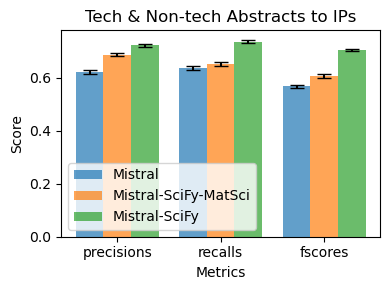

In [67]:
import os
import numpy as np
import json
from collections import defaultdict
from data_utils import load_jsonl
from vis_utils import analyze, plot_grouped_bar_adjustable_width, bootstrap_std


results_path = '../../metrics/technontech2ip_final_scores.json'

with open(results_path, 'rt') as input_file:
    results_all = json.load(input_file)
    
results_all_aggr = {}
for key in results_all:
    aggr_results = analyze(results_all[key],
                                        metrics_keep=[
                                            'precisions',
                                            'recalls',
                                            'fscores'])
    results_all_aggr[key] = aggr_results
    
# Running the function with your dataset
plot_grouped_bar_adjustable_width(results_all_aggr, 
                                  save_path='../figures/technontech2ip_final.pdf',
                                  figsize=(4, 3),
                                 rotation=0, ha='center',
                                 title='Tech & Non-tech Abstracts to IPs')

In [68]:
latex_tbl = results_to_latex(results_all_aggr,
                                        float_fmt="{:.4f}",
                                        caption="Tech & Non-Tech Abstracts to Investigation Proposals",
                                        label="tab:text2ip")
print(latex_tbl)


\begin{table}
\centering
\caption{Tech & Non-Tech Abstracts to Investigation Proposals}
\label{tab:text2ip}
\begin{tabular}{lrrr}
\toprule
Method &              Mistral & Mistral-SciFy-MatSci &        Mistral-SciFy \\
Metric     &                      &                      &                      \\
\midrule
fscores    &  0.5668 $\pm$ 0.0032 &  0.6053 $\pm$ 0.0040 &  0.7039 $\pm$ 0.0025 \\
precisions &  0.6222 $\pm$ 0.0039 &  0.6867 $\pm$ 0.0028 &  0.7219 $\pm$ 0.0028 \\
recalls    &  0.6364 $\pm$ 0.0033 &  0.6507 $\pm$ 0.0040 &  0.7359 $\pm$ 0.0029 \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_19536/460388067.py:52: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return df.to_latex(


## Categories

In [69]:
load_paths = {
    '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/technontech2ip/lora_model_mistral-7b-instruct-v0.3.text2ip_instruct_user_assistant.matsci_and_20k.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds.json': 'Mistral',
    '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/technontech2ip/lora_model_mistral-7b-instruct-v0.3.text2ip_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds.json': 'Mistral-SciFy-MatSci',
    '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/technontech2ip/mistral-7b-instruct-v0.3_preds.json': 'Mistral-SciFy',
    # '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/technontech2claims/lora_model_mistral-7b-instruct-v0.3.text2claims_instruct_user_assistant.matsci_and_20k.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds.json': 'Mistral',
    # '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/technontech2claims/lora_model_mistral-7b-instruct-v0.3.text2claims_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds.json': 'Mistral-SciFy-MatSci',
    # '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/technontech2claims/mistral-7b-instruct-v0.3_preds.json': 'Mistral-SciFy'
    # '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/tech2nontech/mistral-7b-instruct-v0.3_preds.json': 'Mistral',
    # '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/tech2nontech/lora_model_mistral-7b-instruct-v0.3_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm_preds.json': 'Mistral-SciFy-MatSci',
    # '/shared_data0/weiqiuy/nsf-awards/results_gen_bsz1/tech2nontech/lora_model_mistral-7b-instruct-v0.3.tech2nontech_instruct_user_assistant.matsci_and_20k.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds.json': 'Mistral-SciFy'
}

load_path = list(load_paths.keys())[0]
with open(load_path) as input_file:
    data = json.load(input_file)

keep_directorates = ['MPS', 'GEO', 'ENG', 'CSE', 'BIO']

directorates = []
for i in range(len(data['inputs'])):
    if data['inputs'][i]['division'] == 'DMR' \
        or data['inputs'][i]['directorate'] not in keep_directorates:
        directorates.append('DMR')
    else:
        directorates.append(data['inputs'][i]['directorate'])
len(directorates)

6000

In [70]:
# `results_all` is your JSON-loaded raw dict:
#   { "Mistral": {...}, "Mistral-SciFy": {...}, ... }

# `directorates` is your list of length N, e.g.:
#   ["DMR","DMR","ENG",...,"BIO"]

latex = results_to_latex_by_directorate(
    raw_results_all = results_all,
    directorates     = directorates,
    float_fmt        = "{:.4f}",
    sep              = " $\\pm$ ",
    caption          = "Technical + Non-Technical Abstracts to Investigation Proposals",
    label            = "tab:text2ip_detailed",
)
print(latex)


\begin{table}[ht]
\centering
\caption{Technical + Non-Technical Abstracts to Investigation Proposals}
\label{tab:text2ip_detailed}
\begin{tabular}{lrrr}
\toprule
Metric & Mistral & Mistral-SciFy-MatSci & Mistral-SciFy \\
\midrule
\multicolumn{4}{l}{\bfseries DMR} \\
\addlinespace[0.3em]
fscores & 0.5686 $\pm$ 0.0047 & 0.7122 $\pm$ 0.0037 & 0.7218 $\pm$ 0.0034\\
precisions & 0.6539 $\pm$ 0.0058 & 0.7256 $\pm$ 0.0039 & 0.7391 $\pm$ 0.0039\\
recalls & 0.5986 $\pm$ 0.0049 & 0.7440 $\pm$ 0.0040 & 0.7435 $\pm$ 0.0041\\
\addlinespace[0.5em]
\multicolumn{4}{l}{\bfseries BIO} \\
\addlinespace[0.3em]
fscores & 0.5817 $\pm$ 0.0086 & 0.5728 $\pm$ 0.0113 & 0.7081 $\pm$ 0.0078\\
precisions & 0.6393 $\pm$ 0.0106 & 0.6828 $\pm$ 0.0078 & 0.7343 $\pm$ 0.0084\\
recalls & 0.6379 $\pm$ 0.0092 & 0.6262 $\pm$ 0.0127 & 0.7378 $\pm$ 0.0084\\
\addlinespace[0.5em]
\multicolumn{4}{l}{\bfseries ENG} \\
\addlinespace[0.3em]
fscores & 0.5608 $\pm$ 0.0092 & 0.5371 $\pm$ 0.0112 & 0.6944 $\pm$ 0.0074\\
precisions & 0.6